![LIS](LIS.jpg)

# Binary Classification with Logistic Regression
## From Linear Models to Probability Predictions

In the previous class, we learned how linear regression uses gradient descent to find the best-fitting line for predicting numerical outputs. But what if we want to predict **categories** instead of numbers?

In this notebook, we'll build up the mathematical tools needed to understand **logistic regression**—the simplest classification algorithm. We'll see how it extends linear regression to handle binary outcomes (pass/fail, spam/not-spam, yes/no).

We'll cover:
1. The problem with using linear regression for classification
2. The logistic (sigmoid) function
3. Log odds and the connection to linear regression
4. The cost function for classification (cross-entropy loss)
5. Gradient descent for logistic regression
6. Evaluating classification models

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set()

# Set random seed for reproducibility
np.random.seed(42)

## Part 1: Why Linear Regression Fails for Classification

Imagine we want to predict whether a student passes an exam based on hours studied. Our outcomes are:
- **0** = Fail
- **1** = Pass

Let's see what happens if we try to use linear regression:

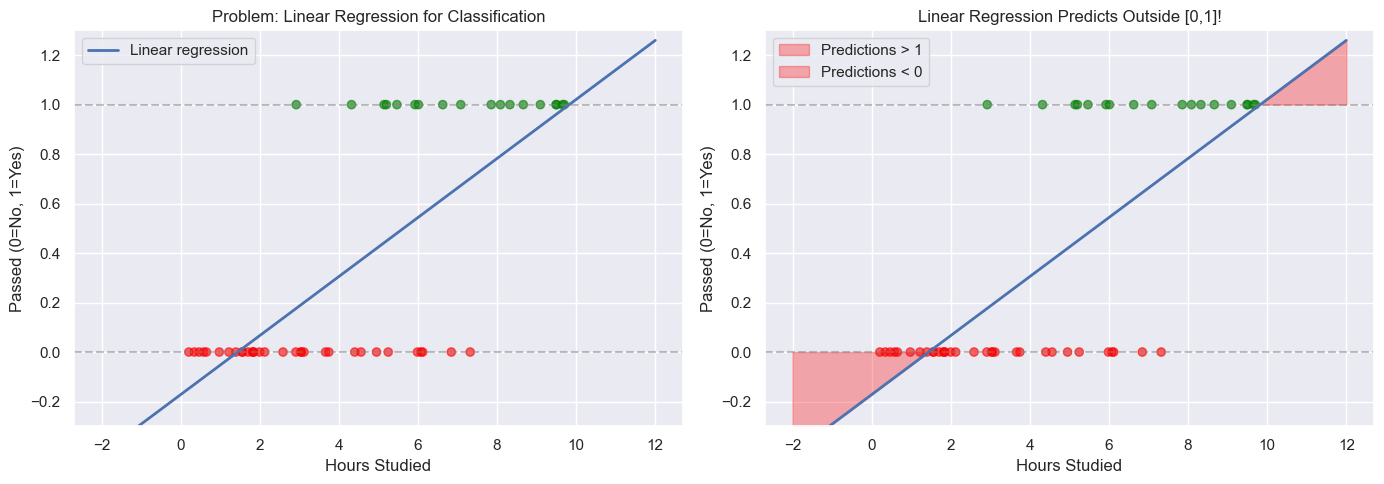

Problems with linear regression for classification:
1. Predictions can be less than 0 or greater than 1
2. We can't interpret outputs as probabilities
3. The relationship between features and probability isn't linear


In [6]:
# Generate sample data: hours studied vs pass/fail
np.random.seed(42)
n_samples = 50

# Students who studied less tend to fail, those who studied more tend to pass
hours_studied = np.random.uniform(0, 10, n_samples)
# Probability of passing increases with hours studied
pass_probability = 1 / (1 + np.exp(-(hours_studied - 5)))
passed = (np.random.random(n_samples) < pass_probability).astype(int)

# Create DataFrame
exam_data = pd.DataFrame({'hours_studied': hours_studied, 'passed': passed})

# Plot with linear regression line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Linear regression attempt
axes[0].scatter(hours_studied, passed, alpha=0.6, c=['red' if p == 0 else 'green' for p in passed])
# Fit linear regression
m, b = np.polyfit(hours_studied, passed, 1)
x_line = np.linspace(-2, 12, 100)
y_line = m * x_line + b
axes[0].plot(x_line, y_line, 'b-', linewidth=2, label='Linear regression')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Hours Studied')
axes[0].set_ylabel('Passed (0=No, 1=Yes)')
axes[0].set_title('Problem: Linear Regression for Classification')
axes[0].set_ylim(-0.3, 1.3)
axes[0].legend()

# Right plot: Highlight the problems
axes[1].scatter(hours_studied, passed, alpha=0.6, c=['red' if p == 0 else 'green' for p in passed])
axes[1].plot(x_line, y_line, 'b-', linewidth=2)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
axes[1].fill_between(x_line, 1, y_line, where=(y_line > 1), alpha=0.3, color='red', label='Predictions > 1')
axes[1].fill_between(x_line, y_line, 0, where=(y_line < 0), alpha=0.3, color='red', label='Predictions < 0')
axes[1].set_xlabel('Hours Studied')
axes[1].set_ylabel('Passed (0=No, 1=Yes)')
axes[1].set_title('Linear Regression Predicts Outside [0,1]!')
axes[1].set_ylim(-0.3, 1.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Problems with linear regression for classification:")
print("1. Predictions can be less than 0 or greater than 1")
print("2. We can't interpret outputs as probabilities")
print("3. The relationship between features and probability isn't linear")

## Part 2: The Logistic (Sigmoid) Function

We need a function that:
1. Takes any input from $-\infty$ to $+\infty$
2. Outputs values **only** between 0 and 1
3. Can be interpreted as a probability

The **logistic function** (also called the **sigmoid function**) does exactly this:

$$\sigma(t) = \frac{1}{1 + e^{-t}}$$

Where:
- $e \approx 2.718$ is Euler's number
- $t$ can be any real number
- The output is always between 0 and 1

/var/folders/zl/smxg40gn42jc6s6xw6n9g3fc0000gn/T/ipykernel_77431/2385181699.py:38: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/NLP/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


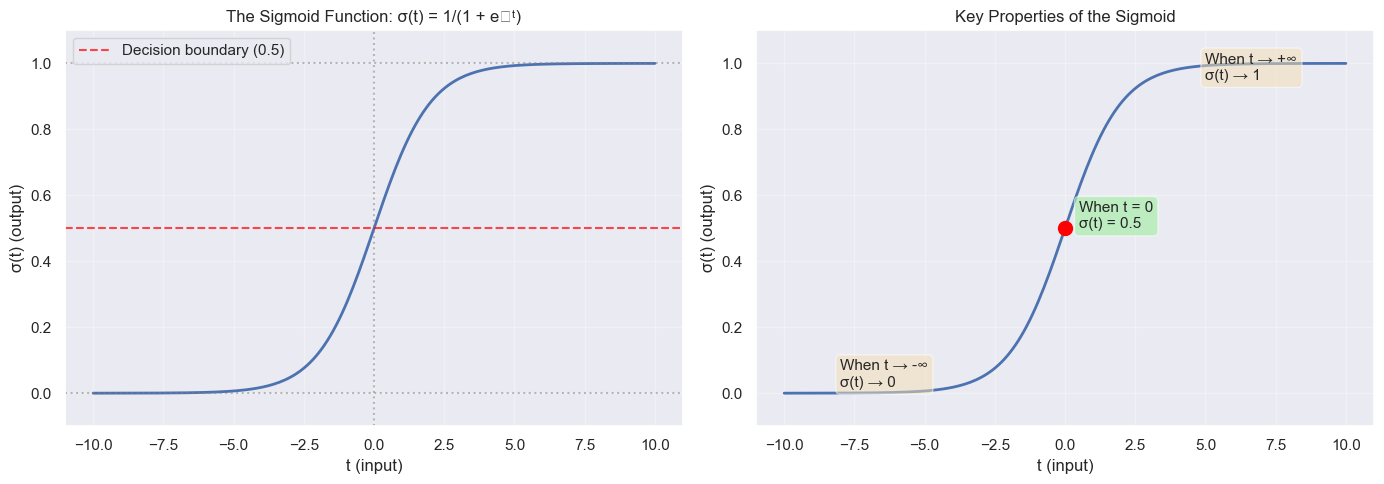

Key properties of the sigmoid function:
  σ(-10) = 0.000045  (very close to 0)
  σ(0)   = 0.500000   (exactly 0.5)
  σ(10)  = 0.999955  (very close to 1)


In [16]:
def sigmoid(t):
    """The logistic/sigmoid function"""
    return 1 / (1 + np.exp(-t))

# Plot the sigmoid function
t = np.linspace(-10, 10, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Basic sigmoid
axes[0].plot(t, sigmoid(t), 'b-', linewidth=2)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Decision boundary (0.5)')
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0].axhline(y=1, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('t (input)')
axes[0].set_ylabel('σ(t) (output)')
axes[0].set_title('The Sigmoid Function: σ(t) = 1/(1 + e⁻ᵗ)')
axes[0].legend()
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(True, alpha=0.3)

# Right: Key properties
axes[1].plot(t, sigmoid(t), 'b-', linewidth=2)
axes[1].annotate('When t → -∞\nσ(t) → 0', xy=(-8, 0.02), fontsize=11,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].annotate('When t → +∞\nσ(t) → 1', xy=(5, 0.95), fontsize=11,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].annotate('When t = 0\nσ(t) = 0.5', xy=(0.5, 0.5), fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
axes[1].scatter([0], [0.5], color='red', s=100, zorder=5)
axes[1].set_xlabel('t (input)')
axes[1].set_ylabel('σ(t) (output)')
axes[1].set_title('Key Properties of the Sigmoid')
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key properties of the sigmoid function:")
print(f"  σ(-10) = {sigmoid(-10):.6f}  (very close to 0)")
print(f"  σ(0)   = {sigmoid(0):.6f}   (exactly 0.5)")
print(f"  σ(10)  = {sigmoid(10):.6f}  (very close to 1)")

## Part 3: Connecting Linear Regression to Logistic Regression

Now we combine our linear model with the sigmoid function. Instead of predicting $y$ directly, we predict the **probability** of $y = 1$:

$$P(y=1|x) = \sigma(\beta_0 + \beta_1 x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

Where:
- $\beta_0$ is the intercept (like $b$ in linear regression)
- $\beta_1$ is the coefficient/slope (like $m$ in linear regression)
- $x$ is our input feature

The linear part ($\beta_0 + \beta_1 x$) can output any value, but the sigmoid "squashes" it into $[0, 1]$.

/var/folders/zl/smxg40gn42jc6s6xw6n9g3fc0000gn/T/ipykernel_77431/1031030700.py:32: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zl/smxg40gn42jc6s6xw6n9g3fc0000gn/T/ipykernel_77431/1031030700.py:32: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/NLP/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/NLP/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


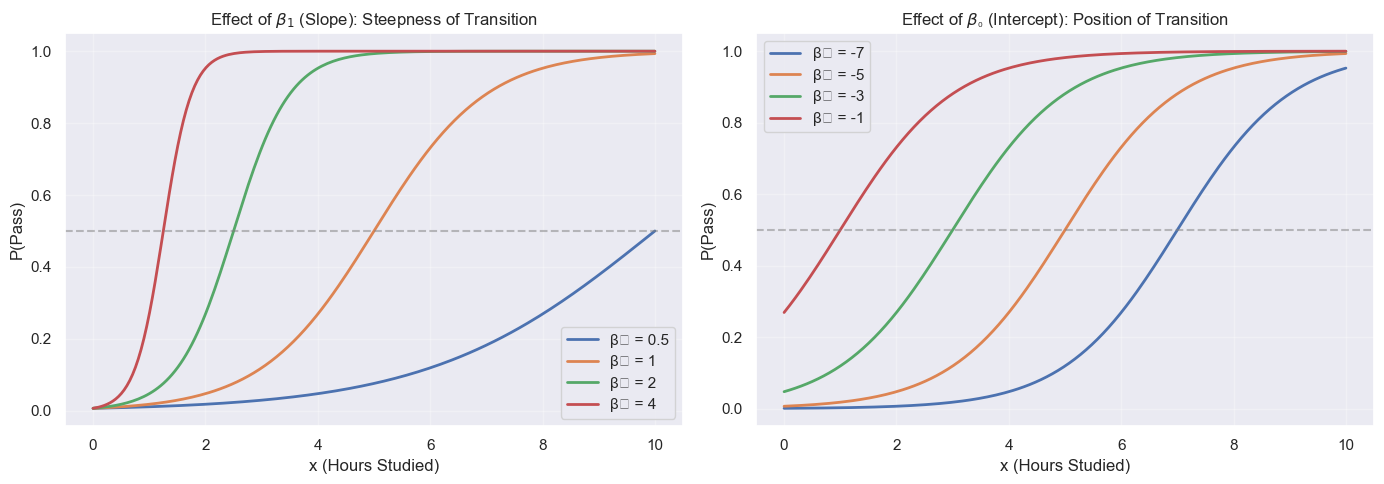

Interpretation of parameters:
• β₁ (slope): Controls how quickly probability changes with x
  - Larger β₁ = sharper transition from 0 to 1
  - Smaller β₁ = more gradual transition

• β₀ (intercept): Controls where the 50% probability point is
  - The decision boundary is at x = -β₀/β₁


In [22]:
# Demonstrate how different parameters affect the sigmoid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(0, 10, 200)

# Left: Effect of β₁ (slope)
beta_0 = -5  # Fixed intercept
for beta_1 in [0.5, 1, 2, 4]:
    y = sigmoid(beta_0 + beta_1 * x)
    axes[0].plot(x, y, linewidth=2, label=f'β₁ = {beta_1}')

axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('x (Hours Studied)')
axes[0].set_ylabel('P(Pass)')
axes[0].set_title('Effect of $β_1$ (Slope): Steepness of Transition')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Effect of β₀ (intercept)
beta_1 = 1  # Fixed slope
for beta_0 in [-7, -5, -3, -1]:
    y = sigmoid(beta_0 + beta_1 * x)
    axes[1].plot(x, y, linewidth=2, label=f'β₀ = {beta_0}')

axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('x (Hours Studied)')
axes[1].set_ylabel('P(Pass)')
axes[1].set_title('Effect of $β_₀$ (Intercept): Position of Transition')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation of parameters:")
print("• β₁ (slope): Controls how quickly probability changes with x")
print("  - Larger β₁ = sharper transition from 0 to 1")
print("  - Smaller β₁ = more gradual transition")
print("\n• β₀ (intercept): Controls where the 50% probability point is")
print("  - The decision boundary is at x = -β₀/β₁")

### Understanding Log Odds

There's a beautiful mathematical interpretation of logistic regression. If we rearrange the logistic equation, we get:

$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x$$

The left side is called the **log odds** (or **logit**):

- **Odds**: The ratio of success to failure probability: $\frac{p}{1-p}$
  - If $p = 0.75$, odds = $\frac{0.75}{0.25} = 3$ ("3 to 1 odds")
  - If $p = 0.5$, odds = $\frac{0.5}{0.5} = 1$ ("even odds")
  
- **Log odds**: The natural logarithm of the odds
  - Transforms odds from $(0, \infty)$ to $(-\infty, +\infty)$
  - Log odds of 0 means $p = 0.5$ (50-50 chance)
  - Positive log odds mean $p > 0.5$ (more likely to succeed)
  - Negative log odds mean $p < 0.5$ (more likely to fail)

**Key insight**: In logistic regression, the log odds are a linear function of $x$!

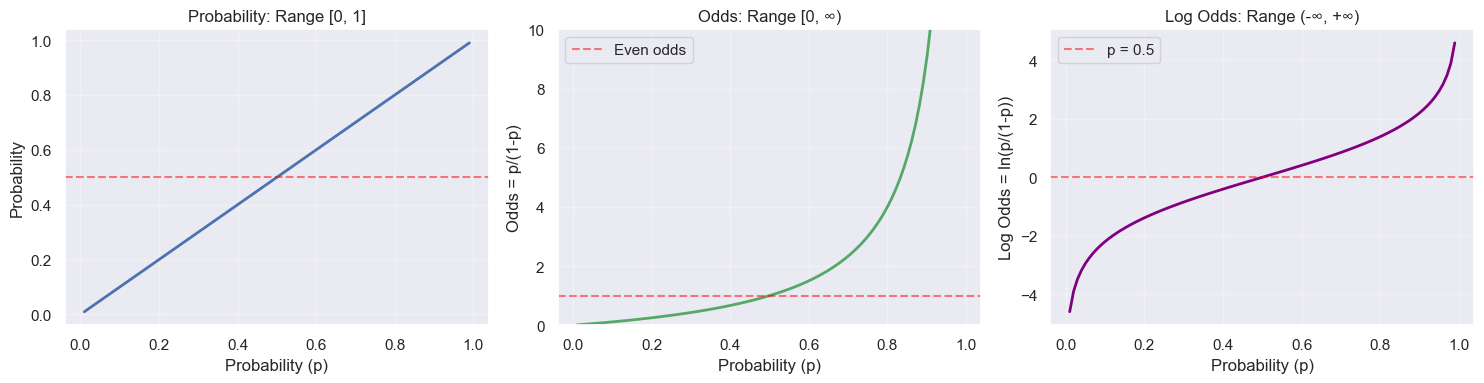

Example: A student has a 75% chance of passing
  Probability: 0.75
  Odds: 3.00 (3 to 1)
  Log odds: 1.10


In [24]:
# Visualize the relationship between probability, odds, and log odds
p = np.linspace(0.01, 0.99, 100)
odds = p / (1 - p)
log_odds = np.log(odds)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Probability
axes[0].plot(p, p, 'b-', linewidth=2)
axes[0].set_xlabel('Probability (p)')
axes[0].set_ylabel('Probability')
axes[0].set_title('Probability: Range [0, 1]')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Odds
axes[1].plot(p, odds, 'g-', linewidth=2)
axes[1].set_xlabel('Probability (p)')
axes[1].set_ylabel('Odds = p/(1-p)')
axes[1].set_title('Odds: Range [0, ∞)')
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Even odds')
axes[1].set_ylim(0, 10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Log odds
axes[2].plot(p, log_odds, 'purple', linewidth=2)
axes[2].set_xlabel('Probability (p)')
axes[2].set_ylabel('Log Odds = ln(p/(1-p))')
axes[2].set_title('Log Odds: Range (-∞, +∞)')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='p = 0.5')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Example calculations
print("Example: A student has a 75% chance of passing")
prob = 0.75
print(f"  Probability: {prob}")
print(f"  Odds: {prob/(1-prob):.2f} (3 to 1)")
print(f"  Log odds: {np.log(prob/(1-prob)):.2f}")

## Part 4: The Cost Function (Cross-Entropy Loss)

In linear regression, we minimized Mean Squared Error. For classification, MSE doesn't work well because:
1. The sigmoid function creates a non-convex cost surface
2. We need to penalize confident wrong predictions more heavily

Instead, we use **cross-entropy loss** (also called **log loss**):

For a single prediction:
$$\text{Loss}(y, \hat{p}) = -[y \cdot \ln(\hat{p}) + (1-y) \cdot \ln(1-\hat{p})]$$

Where:
- $y$ is the true label (0 or 1)
- $\hat{p}$ is our predicted probability

**Intuition**: 
- If $y = 1$, we want $\hat{p}$ close to 1, so loss = $-\ln(\hat{p})$
- If $y = 0$, we want $\hat{p}$ close to 0, so loss = $-\ln(1-\hat{p})$

The full cost function averages over all $n$ examples:

$$J(\beta_0, \beta_1) = -\frac{1}{n}\sum_{i=1}^{n}[y_i \cdot \ln(\hat{p}_i) + (1-y_i) \cdot \ln(1-\hat{p}_i)]$$

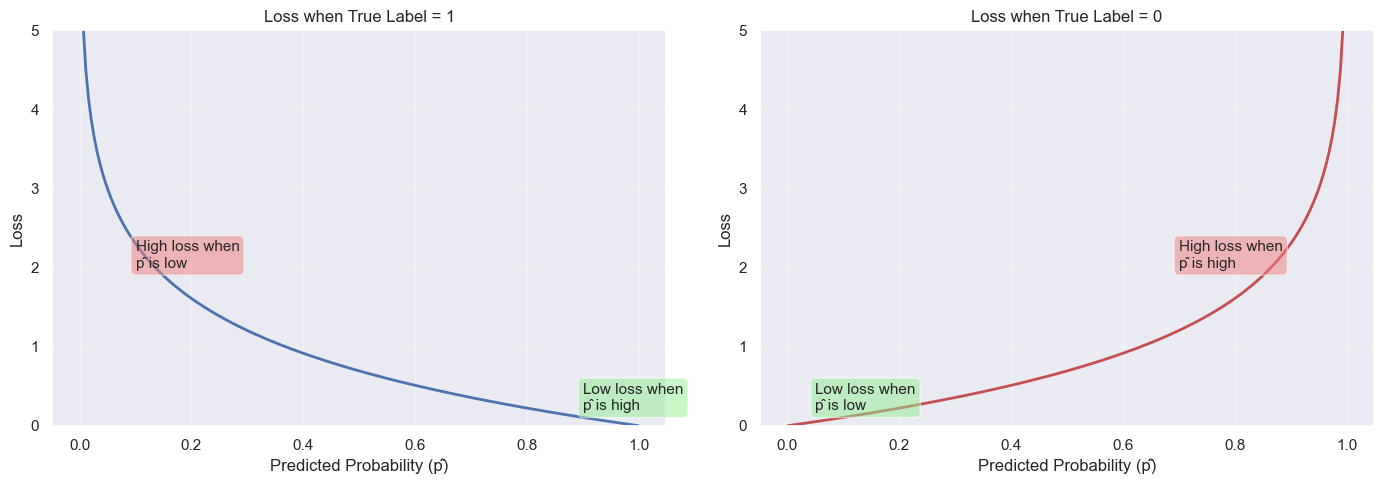

Key insight: Cross-entropy heavily penalizes confident wrong predictions!

Example losses when true label = 1:
  Predict p̂ = 0.99: loss = 0.0101 (correct, low loss)
  Predict p̂ = 0.50: loss = 0.6931 (uncertain)
  Predict p̂ = 0.01: loss = 4.6052 (wrong, high loss!)


In [26]:
# Visualize why cross-entropy loss works
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p_pred = np.linspace(0.001, 0.999, 200)

# Left: Loss when true label is 1
loss_when_y1 = -np.log(p_pred)
axes[0].plot(p_pred, loss_when_y1, 'b-', linewidth=2)
axes[0].set_xlabel('Predicted Probability (p̂)')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss when True Label = 1')
axes[0].annotate('Low loss when\np̂ is high', xy=(0.9, 0.2), fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
axes[0].annotate('High loss when\np̂ is low', xy=(0.1, 2), fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
axes[0].set_ylim(0, 5)
axes[0].grid(True, alpha=0.3)

# Right: Loss when true label is 0
loss_when_y0 = -np.log(1 - p_pred)
axes[1].plot(p_pred, loss_when_y0, 'r-', linewidth=2)
axes[1].set_xlabel('Predicted Probability (p̂)')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss when True Label = 0')
axes[1].annotate('Low loss when\np̂ is low', xy=(0.05, 0.2), fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
axes[1].annotate('High loss when\np̂ is high', xy=(0.7, 2), fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
axes[1].set_ylim(0, 5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: Cross-entropy heavily penalizes confident wrong predictions!")
print(f"\nExample losses when true label = 1:")
print(f"  Predict p̂ = 0.99: loss = {-np.log(0.99):.4f} (correct, low loss)")
print(f"  Predict p̂ = 0.50: loss = {-np.log(0.50):.4f} (uncertain)")
print(f"  Predict p̂ = 0.01: loss = {-np.log(0.01):.4f} (wrong, high loss!)")

## Part 5: Gradient Descent for Logistic Regression

Just like in linear regression, we use gradient descent to find the optimal parameters. We compute the derivatives of the cost function:

$$\frac{\partial J}{\partial \beta_0} = \frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i - y_i)$$

$$\frac{\partial J}{\partial \beta_1} = \frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i - y_i) \cdot x_i$$

Where $\hat{p}_i = \sigma(\beta_0 + \beta_1 x_i)$

These look remarkably similar to linear regression! The update rules are:

$$\beta_0^{\text{new}} = \beta_0^{\text{old}} - \alpha \cdot \frac{\partial J}{\partial \beta_0}$$

$$\beta_1^{\text{new}} = \beta_1^{\text{old}} - \alpha \cdot \frac{\partial J}{\partial \beta_1}$$

In [ ]:
def logistic_regression_gradient_descent(X, y, learning_rate=0.1, num_iterations=1000):
    """
    Implement logistic regression using gradient descent.
    
    Parameters:
    -----------
    X : array of shape (n_samples,)
        Input features
    y : array of shape (n_samples,)
        Binary labels (0 or 1)
    learning_rate : float
        Step size for gradient descent
    num_iterations : int
        Number of iterations to run
    
    Returns:
    --------
    beta_0, beta_1 : floats
        Learned parameters
    cost_history : list
        Cost at each iteration
    """
    n = len(y)
    
    # Initialize parameters
    beta_0 = 0
    beta_1 = 0
    
    cost_history = []
    beta_0_history = [beta_0]
    beta_1_history = [beta_1]
    
    for i in range(num_iterations):
        # Compute predictions
        z = beta_0 + beta_1 * X
        p_hat = sigmoid(z)
        
        # Compute cost (cross-entropy)
        # Add small epsilon to avoid log(0)
        epsilon = 1e-15
        cost = -np.mean(y * np.log(p_hat + epsilon) + (1 - y) * np.log(1 - p_hat + epsilon))
        cost_history.append(cost)
        
        # Compute gradients
        error = p_hat - y
        d_beta_0 = np.mean(error)
        d_beta_1 = np.mean(error * X)
        
        # Update parameters
        beta_0 = beta_0 - learning_rate * d_beta_0
        beta_1 = beta_1 - learning_rate * d_beta_1
        
        beta_0_history.append(beta_0)
        beta_1_history.append(beta_1)
    
    return beta_0, beta_1, cost_history, beta_0_history, beta_1_history

# Train on our exam data
X = exam_data['hours_studied'].values
y = exam_data['passed'].values

beta_0, beta_1, costs, b0_hist, b1_hist = logistic_regression_gradient_descent(
    X, y, learning_rate=0.5, num_iterations=500
)

print(f"Learned parameters:")
print(f"  β₀ (intercept) = {beta_0:.4f}")
print(f"  β₁ (slope) = {beta_1:.4f}")
print(f"\nDecision boundary: x = {-beta_0/beta_1:.2f} hours")
print(f"(Students who study more than {-beta_0/beta_1:.2f} hours are predicted to pass)")

In [ ]:
# Visualize the training process
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: Cost over iterations
axes[0].plot(costs, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost (Cross-Entropy)')
axes[0].set_title('Cost Decreases During Training')
axes[0].grid(True, alpha=0.3)

# Middle: Data with learned sigmoid
x_plot = np.linspace(0, 10, 200)
p_plot = sigmoid(beta_0 + beta_1 * x_plot)

axes[1].scatter(X, y, c=['red' if yi == 0 else 'green' for yi in y], 
               alpha=0.6, s=50, label='Data')
axes[1].plot(x_plot, p_plot, 'b-', linewidth=2, label='Logistic regression')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=-beta_0/beta_1, color='purple', linestyle='--', 
               alpha=0.7, label=f'Decision boundary ({-beta_0/beta_1:.1f}h)')
axes[1].set_xlabel('Hours Studied')
axes[1].set_ylabel('P(Pass)')
axes[1].set_title('Learned Logistic Regression Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Right: Evolution of sigmoid during training
for i, idx in enumerate([0, 10, 50, 100, 499]):
    b0, b1 = b0_hist[idx], b1_hist[idx]
    p = sigmoid(b0 + b1 * x_plot)
    alpha = 0.3 + 0.7 * (i / 4)  # Increase opacity
    axes[2].plot(x_plot, p, linewidth=2, alpha=alpha, label=f'Iter {idx}')

axes[2].scatter(X, y, c=['red' if yi == 0 else 'green' for yi in y], 
               alpha=0.3, s=30)
axes[2].set_xlabel('Hours Studied')
axes[2].set_ylabel('P(Pass)')
axes[2].set_title('Model Evolution During Training')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 6: Evaluating Classification Models

Unlike regression where we use $R^2$, classification requires different metrics. When we make predictions, there are four possible outcomes:

|  | Predicted Positive | Predicted Negative |
|--|-------------------|-------------------|
| **Actually Positive** | True Positive (TP) | False Negative (FN) |
| **Actually Negative** | False Positive (FP) | True Negative (TN) |

From these, we compute four key metrics:

### 1. Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
The fraction of all predictions that are correct. Simple but can be misleading with imbalanced data.

### 2. Precision
$$\text{Precision} = \frac{TP}{TP + FP}$$
Of all the positive predictions, how many were actually positive? Important when false positives are costly.

### 3. Recall (Sensitivity)
$$\text{Recall} = \frac{TP}{TP + FN}$$
Of all actual positives, how many did we correctly identify? Important when false negatives are costly.

### 4. F1 Score
$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2TP}{2TP + FP + FN}$$
The harmonic mean of precision and recall. Balances both concerns.

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Make predictions using our trained model
p_pred = sigmoid(beta_0 + beta_1 * X)
y_pred = (p_pred >= 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Predicted Fail', 'Predicted Pass'],
           yticklabels=['Actually Fail', 'Actually Pass'])
axes[0].set_title('Confusion Matrix')

# Right: Metrics visualization
metrics = {
    'Accuracy': accuracy_score(y, y_pred),
    'Precision': precision_score(y, y_pred),
    'Recall': recall_score(y, y_pred),
    'F1 Score': f1_score(y, y_pred)
}

bars = axes[1].bar(metrics.keys(), metrics.values(), color=['steelblue', 'coral', 'seagreen', 'purple'])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Metrics')
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Extract values from confusion matrix
TN, FP, FN, TP = cm.ravel()
print(f"Confusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {TN} (correctly predicted fail)")
print(f"  False Positives (FP): {FP} (incorrectly predicted pass)")
print(f"  False Negatives (FN): {FN} (incorrectly predicted fail)")
print(f"  True Positives (TP):  {TP} (correctly predicted pass)")

### Which Metric Should You Use?

The choice depends on your application:

| Scenario | Priority | Why |
|----------|----------|-----|
| Spam detection | Precision | False positives (losing real emails) are costly |
| Disease screening | Recall | False negatives (missing sick patients) are dangerous |
| Balanced problems | F1 Score | Balances precision and recall |
| Equal costs | Accuracy | All errors equally bad |

**Warning**: Accuracy can be misleading! If 95% of emails are not spam, a model that predicts "not spam" for everything has 95% accuracy but is useless.

## Part 7: Logistic Regression in Python with Scikit-Learn

In practice, we use optimized libraries like `scikit-learn`. Let's see how to fit a logistic regression model the easy way:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Generate a larger dataset for better demonstration
np.random.seed(42)
n_samples = 200

hours = np.random.uniform(0, 12, n_samples)
# True relationship: probability of passing increases with hours studied
true_prob = sigmoid(-5 + 1 * hours)  # Decision boundary at 5 hours
passed = (np.random.random(n_samples) < true_prob).astype(int)

# Prepare data
X = hours.reshape(-1, 1)  # sklearn needs 2D array
y = passed

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

In [ ]:
# Fit logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# View learned parameters
print("Learned parameters:")
print(f"  Intercept (β₀): {model.intercept_[0]:.4f}")
print(f"  Coefficient (β₁): {model.coef_[0][0]:.4f}")
print(f"\nDecision boundary: {-model.intercept_[0]/model.coef_[0][0]:.2f} hours")

In [ ]:
# Make predictions on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of class 1

# Evaluate performance
print("Classification Report on Test Set:")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

In [ ]:
# Visualize the model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Training data with model
x_plot = np.linspace(0, 12, 200).reshape(-1, 1)
p_plot = model.predict_proba(x_plot)[:, 1]

axes[0].scatter(X_train, y_train, c=['red' if yi == 0 else 'green' for yi in y_train], 
               alpha=0.5, label='Training data')
axes[0].plot(x_plot, p_plot, 'b-', linewidth=2, label='Model')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
db = -model.intercept_[0]/model.coef_[0][0]
axes[0].axvline(x=db, color='purple', linestyle='--', alpha=0.7, 
               label=f'Decision boundary ({db:.1f}h)')
axes[0].set_xlabel('Hours Studied')
axes[0].set_ylabel('P(Pass)')
axes[0].set_title('Training Data')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Test data predictions
axes[1].scatter(X_test, y_test, c=['red' if yi == 0 else 'green' for yi in y_test], 
               alpha=0.5, s=100, label='Actual', edgecolors='black')
axes[1].scatter(X_test, y_pred, c=['red' if yi == 0 else 'green' for yi in y_pred], 
               alpha=0.5, s=100, marker='x', label='Predicted')
axes[1].plot(x_plot, p_plot, 'b-', linewidth=2, alpha=0.5)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=db, color='purple', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Hours Studied')
axes[1].set_ylabel('Outcome')
axes[1].set_title('Test Data: Actual vs Predicted')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

We've built up the key ideas for binary classification with logistic regression:

1. **The problem**: Linear regression fails for classification because it predicts outside [0,1]

2. **The sigmoid function**: Squashes any input into the range (0,1), interpretable as probability
   $$\sigma(t) = \frac{1}{1 + e^{-t}}$$

3. **Log odds**: The log odds are a linear function of features
   $$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x$$

4. **Cross-entropy loss**: The cost function for classification that heavily penalizes confident wrong predictions
   $$J = -\frac{1}{n}\sum[y\ln(\hat{p}) + (1-y)\ln(1-\hat{p})]$$

5. **Gradient descent**: Same principle as linear regression—compute gradients, update parameters

6. **Evaluation metrics**: Precision, recall, F1, and accuracy—choose based on your problem

This same pattern—probability model + cost function + gradient descent—extends to neural networks, where the models are more complex but the optimization principle is identical.

## Exercises

### Exercise 1: Effect of Learning Rate
Try different learning rates in gradient descent. What happens with very small vs very large values?

In [ ]:
# Exercise 1: Compare different learning rates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

learning_rates = [0.01, 0.5, 2.0]

for ax, lr in zip(axes, learning_rates):
    _, _, costs, _, _ = logistic_regression_gradient_descent(
        X.flatten(), y, learning_rate=lr, num_iterations=200
    )
    
    ax.plot(costs, 'b-', linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Cost')
    ax.set_title(f'Learning Rate α = {lr}')
    ax.grid(True, alpha=0.3)
    ax.text(0.5, 0.95, f'Final cost: {costs[-1]:.4f}', 
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Observations:")
print("- Too small (0.01): Slow convergence, may not reach minimum")
print("- Just right (0.5): Steady convergence")
print("- Too large (2.0): May oscillate or diverge")

### Exercise 2: Decision Threshold
We've been using 0.5 as the threshold for classification. What happens if we change it?

In [ ]:
# Exercise 2: Effect of decision threshold
thresholds = [0.3, 0.5, 0.7]

print("Effect of Different Decision Thresholds:")
print("=" * 60)

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    print(f"\nThreshold = {thresh}:")
    print(f"  Precision: {prec:.3f}  |  Recall: {rec:.3f}  |  F1: {f1:.3f}")

print("\n" + "=" * 60)
print("Lower threshold → More positive predictions → Higher recall, lower precision")
print("Higher threshold → Fewer positive predictions → Lower recall, higher precision")

### Exercise 3: Making Predictions
Use the trained model to predict outcomes for new students.

In [ ]:
# Exercise 3: Make predictions for new students
new_hours = np.array([2, 4, 5, 6, 8]).reshape(-1, 1)

probabilities = model.predict_proba(new_hours)[:, 1]
predictions = model.predict(new_hours)

print("Predictions for new students:")
print("-" * 50)
for h, prob, pred in zip(new_hours.flatten(), probabilities, predictions):
    result = "Pass" if pred == 1 else "Fail"
    print(f"  {h} hours studied → P(Pass) = {prob:.2%} → Prediction: {result}")